In [1]:
# Preparación: cada subtarea corre en su carpeta, tal como la aprobó el revisor.
import os
from pathlib import Path
from IPython.display import Image, display

RAIZ = Path.cwd()

def mostrar_figuras(carpeta):
    for png in sorted(Path(carpeta).rglob("*.png")):
        display(Image(filename=str(png)))

# S2·MAR — ANN: mide el trade-off recall / latencia

**MMIA 6013 · Semana 2 · Martes** · Entrega: notebook `semana2_ann.ipynb`

Tres partes: (1) kNN exacto — medir cómo (no) escala; (2) Mini-IVF con KMeans — recall@10 vs. speedup según nprobe; (3) Qdrant embebido (`:memory:`) con filtros de metadata. Requisitos: `numpy`, `scikit-learn`, `matplotlib`; `qdrant-client` opcional (la parte 3 se salta sola si no está).

## Setup

El setup define el terreno común de las tres partes:

- **Datos sintéticos con estructura** (`datos_realistas`): embeddings de d = 128 dimensiones como mezcla de 200 «temas» gaussianos fijos. Los embeddings reales viven agrupados por tema — crucial para que IVF tenga sentido (con ruido uniforme, ningún índice por clusters funciona). Base y consultas comparten los mismos temas, como en un corpus real.
- **`normalizar`**: lleva los vectores a norma 1; así el producto punto es el coseno. Vive en el setup porque las Partes 2 y 3 la usan aunque no se haya resuelto el ejercicio 1.1.
- **Semillas de la sesión**: Parte 1 — semilla de datos 42 y de consultas 123; Parte 2 — rng de datos 7, centros de temas 2026 y `KMeans(random_state=7)`.
- El código de esta sección (imports, `datos_realistas`, `normalizar`) se ejecuta en la primera celda de código, junto con la Parte 1.

## Parte 1 — kNN exacto: latencia vs. N

Verificacion knn_exacto vs. argsort naive: OK
N =  10,000 | latencia media =   0.1183 ms | std =  0.0244 ms | N·d = 1,280,000 mult./consulta
N =  50,000 | latencia media =   0.5710 ms | std =  0.1026 ms | N·d = 6,400,000 mult./consulta
N = 100,000 | latencia media =   1.4183 ms | std =  0.6236 ms | N·d = 12,800,000 mult./consulta


N = 200,000 | latencia media =   2.4964 ms | std =  0.4687 ms | N·d = 25,600,000 mult./consulta

--- Resumen Parte 1: kNN exacto ---
N =  10,000: 0.1183 ms de media (0.0244 ms std) -> 0.012 us por vector
N =  50,000: 0.5710 ms de media (0.1026 ms std) -> 0.011 us por vector
N = 100,000: 1.4183 ms de media (0.6236 ms std) -> 0.014 us por vector
N = 200,000: 2.4964 ms de media (0.4687 ms std) -> 0.012 us por vector
Ajuste lineal: latencia(ms) = 0.0127 us/vector * N + 0.0082 ms
R^2 del ajuste lineal: 0.991536
Crecimiento observado 200k/10k = 21.106 (ideal lineal = 20) -> factor_crecimiento_lineal = 1.0553
¿Crecimiento lineal (O(N·d))? SI

Figura guardada: t1_latencia_vs_N.png
Resultados guardados: resultados.json


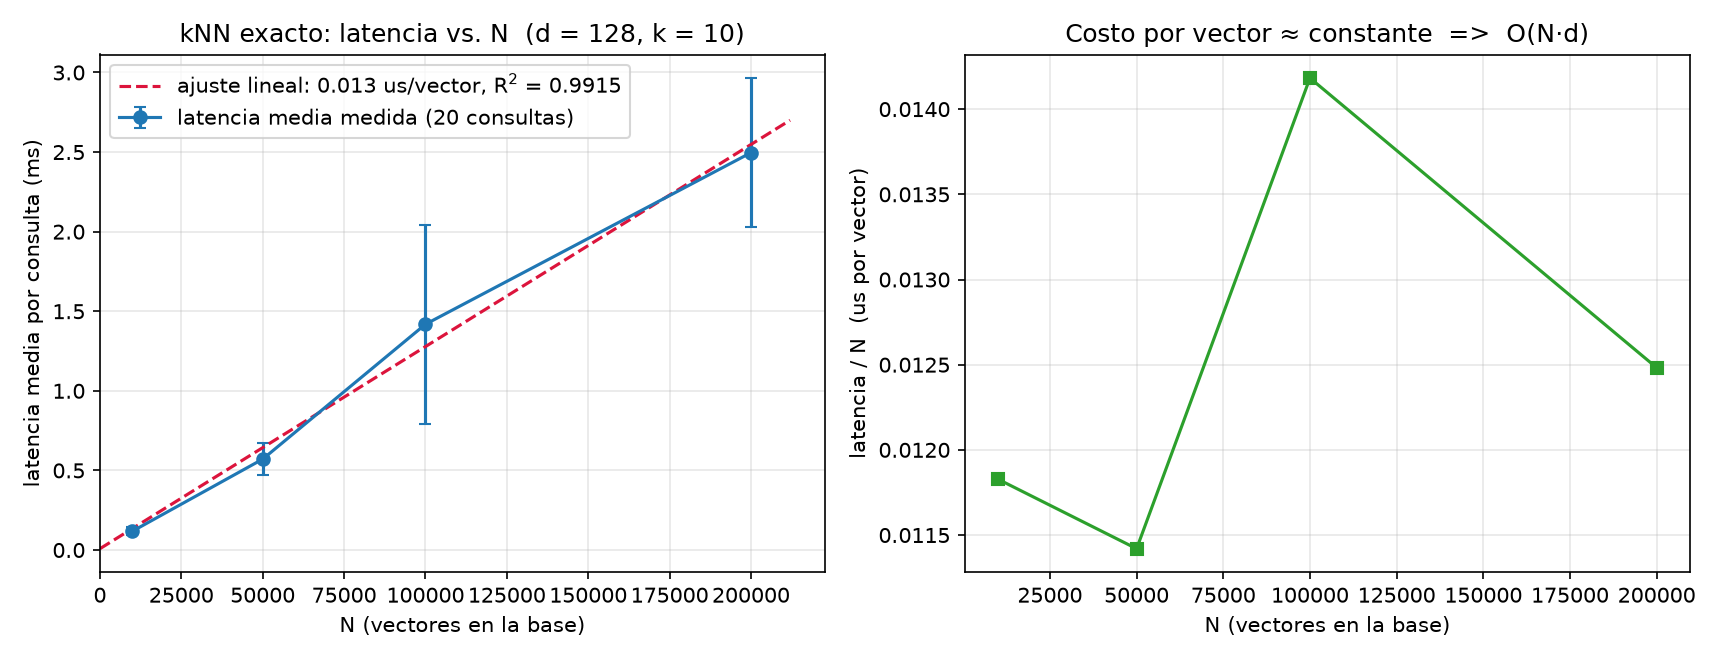

In [2]:
# Subtarea T1: código aprobado (se ejecuta en trabajo/T1/)
os.chdir(RAIZ / 'trabajo' / 'T1')

# -*- coding: utf-8 -*-
"""
T1 — Setup + Parte 1: kNN exacto, latencia vs. N
=================================================
- Setup (código dado): datos_realistas(N) genera N vectores d=128 alrededor de
  200 centros gaussianos fijos (semilla fija); normalizar() lleva cada vector
  a norma 1.
- knn_exacto(consulta, base, k): kNN exacto sobre vectores normalizados usando
  producto punto (≡ similitud coseno). Costo O(N·d).
- Se mide el tiempo medio de consulta para N = 10_000, 50_000, 100_000, 200_000
  (20 consultas por tamaño, media en ms), se grafica latencia vs. N y se
  verifica que el crecimiento es lineal (O(N·d)).

Salidas (carpeta actual): resultados.json, t1_latencia_vs_N.png
"""

import json
import time

import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# Setup (código dado del curso)
# ----------------------------------------------------------------------
D = 128            # dimensión de los vectores
N_CENTROS = 200    # centros gaussianos fijos
SEMILLA_DATOS = 42
SEMILLA_CONSULTAS = 123


def normalizar(X):
    """Normaliza cada fila de X a norma 1 (float32)."""
    X = np.asarray(X, dtype=np.float32)
    normas = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.maximum(normas, 1e-12)


def datos_realistas(N, semilla=SEMILLA_DATOS, d=D, n_centros=N_CENTROS):
    """N vectores d-dimensionales 'realistas': mezcla de n_centros gaussianos fijos.

    Cada vector = centro elegido al azar + ruido gaussiano. Con la misma semilla
    los centros (y los datos) son deterministas.
    """
    rng = np.random.default_rng(semilla)
    centros = rng.normal(0.0, 1.0, size=(n_centros, d))        # 200 centros fijos
    asign = rng.integers(0, n_centros, size=N)                 # centro de cada vector
    X = centros[asign] + rng.normal(0.0, 0.3, size=(N, d))     # ruido alrededor del centro
    return X.astype(np.float32)


# ----------------------------------------------------------------------
# Ejercicio 1.1 — kNN exacto (vectores normalizados -> producto punto)
# ----------------------------------------------------------------------
def knn_exacto(consulta, base, k=10):
    """kNN exacto de `consulta` contra `base` (ambas normalizadas a norma 1).

    Similitud = producto punto (≡ coseno). Costo O(N·d): N productos punto
    de dimensión d. Devuelve (índices, scores) de los k mejores, ordenados desc.
    """
    scores = base @ consulta                              # O(N·d)
    k_eff = min(int(k), base.shape[0])
    idx = np.argpartition(-scores, k_eff - 1)[:k_eff]     # top-k sin ordenar
    idx = idx[np.argsort(-scores[idx])]                   # ordenar solo los k
    return idx, scores[idx]


# --- verificación rápida contra una ordenación naive (sanity check) ---
_base_chk = normalizar(datos_realistas(500, semilla=7))
_idx_chk, _sc_chk = knn_exacto(_base_chk[0], _base_chk, 10)
_idx_naive = np.argsort(-(_base_chk @ _base_chk[0]))[:10]
verificacion_knn = bool(np.array_equal(_idx_chk, _idx_naive))
print(f"Verificacion knn_exacto vs. argsort naive: {'OK' if verificacion_knn else 'FALLO'}")
del _base_chk, _idx_chk, _sc_chk, _idx_naive

# ----------------------------------------------------------------------
# Medición de latencia: N = 10k, 50k, 100k, 200k — 20 consultas por tamaño
# ----------------------------------------------------------------------
K = 10
N_VALORES = [10_000, 50_000, 100_000, 200_000]
N_CONSULTAS = 20   # repeticiones por tamaño (se reporta la media en ms)

consultas = normalizar(datos_realistas(N_CONSULTAS, semilla=SEMILLA_CONSULTAS))

latencias_ms = {}  # N -> array con los 20 tiempos individuales (ms)
for N in N_VALORES:
    base = normalizar(datos_realistas(N))                 # base de N vectores normalizados
    for _ in range(3):                                    # warmup (BLAS/caché, no se mide)
        knn_exacto(consultas[0], base, K)
    tiempos = np.empty(N_CONSULTAS, dtype=np.float64)
    for i in range(N_CONSULTAS):
        q = np.ascontiguousarray(consultas[i], dtype=np.float32)
        t0 = time.perf_counter()
        knn_exacto(q, base, K)
        t1 = time.perf_counter()
        tiempos[i] = (t1 - t0) * 1000.0
    latencias_ms[N] = tiempos
    print(f"N = {N:>7,d} | latencia media = {tiempos.mean():8.4f} ms "
          f"| std = {tiempos.std(ddof=1):7.4f} ms | N·d = {N * D:,d} mult./consulta")
    del base

# ----------------------------------------------------------------------
# Análisis: ¿el crecimiento es lineal (O(N·d))?
# ----------------------------------------------------------------------
Ns = np.array(N_VALORES, dtype=np.float64)
medias = np.array([latencias_ms[N].mean() for N in N_VALORES], dtype=np.float64)
stds = np.array([latencias_ms[N].std(ddof=1) for N in N_VALORES], dtype=np.float64)

# Ajuste lineal: latencia(ms) ≈ pendiente·N + intercepto
pendiente, intercepto = np.polyfit(Ns, medias, 1)
pred = pendiente * Ns + intercepto
ss_res = float(np.sum((medias - pred) ** 2))
ss_tot = float(np.sum((medias - medias.mean()) ** 2))
r2 = 1.0 - ss_res / ss_tot

# Factor de crecimiento lineal: crecimiento observado (200k vs 10k) dividido
# por el crecimiento ideal si fuera exactamente O(N) (= 20). ≈ 1 => lineal.
razon_observada = float(medias[-1] / medias[0])
razon_ideal = float(N_VALORES[-1] / N_VALORES[0])
factor_crecimiento_lineal = razon_observada / razon_ideal

# Factores entre tamaños consecutivos (observado vs. ideal lineal)
factores_consecutivos = {}
for i in range(1, len(N_VALORES)):
    n0, n1 = N_VALORES[i - 1], N_VALORES[i]
    factores_consecutivos[f"{n0}_a_{n1}"] = {
        "observado": float(medias[i] / medias[i - 1]),
        "ideal_lineal": float(n1 / n0),
    }

ms_por_vector = medias / Ns  # costo por vector (debe ser ≈ constante si O(N·d))
es_lineal = bool(r2 > 0.99 and 0.5 <= factor_crecimiento_lineal <= 2.0)

print("\n--- Resumen Parte 1: kNN exacto ---")
for N, m, s in zip(N_VALORES, medias, stds):
    print(f"N = {N:>7,d}: {m:.4f} ms de media ({s:.4f} ms std) "
          f"-> {m / N * 1e3:.3f} us por vector")
print(f"Ajuste lineal: latencia(ms) = {pendiente * 1e3:.4f} us/vector * N + {intercepto:.4f} ms")
print(f"R^2 del ajuste lineal: {r2:.6f}")
print(f"Crecimiento observado 200k/10k = {razon_observada:.3f} "
      f"(ideal lineal = {razon_ideal:.0f}) -> factor_crecimiento_lineal = {factor_crecimiento_lineal:.4f}")
print(f"¿Crecimiento lineal (O(N·d))? {'SI' if es_lineal else 'REVISAR'}")

# ----------------------------------------------------------------------
# Figura: latencia vs. N
# ----------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))

ax = axes[0]
ax.errorbar(Ns, medias, yerr=stds, fmt="o-", color="#1f77b4", capsize=3,
            label="latencia media medida (20 consultas)")
xs = np.linspace(0.0, Ns.max() * 1.06, 200)
ax.plot(xs, pendiente * xs + intercepto, "--", color="crimson",
        label=f"ajuste lineal: {pendiente * 1e3:.3f} us/vector, R$^2$ = {r2:.4f}")
ax.set_xlabel("N (vectores en la base)")
ax.set_ylabel("latencia media por consulta (ms)")
ax.set_title(f"kNN exacto: latencia vs. N  (d = {D}, k = {K})")
ax.set_xlim(left=0)
ax.legend(loc="upper left")
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(Ns, ms_por_vector * 1e3, "s-", color="#2ca02c")
ax.set_xlabel("N (vectores en la base)")
ax.set_ylabel("latencia / N  (us por vector)")
ax.set_title("Costo por vector ≈ constante  =>  O(N·d)")
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig("t1_latencia_vs_N.png", dpi=150)
plt.close(fig)
print("\nFigura guardada: t1_latencia_vs_N.png")

# ----------------------------------------------------------------------
# resultados.json
# ----------------------------------------------------------------------
resultados = {
    "subtarea": "T1_setup_knn_exacto_latencia_vs_N",
    "parametros": {
        "d": int(D),
        "n_centros_gaussianos": int(N_CENTROS),
        "semilla_datos": int(SEMILLA_DATOS),
        "semilla_consultas": int(SEMILLA_CONSULTAS),
        "k": int(K),
        "valores_N": [int(n) for n in N_VALORES],
        "n_consultas_por_N": int(N_CONSULTAS),
    },
    "latencia_media_ms_por_N": {str(int(N)): float(latencias_ms[N].mean()) for N in N_VALORES},
    "latencia_std_ms_por_N": {str(int(N)): float(latencias_ms[N].std(ddof=1)) for N in N_VALORES},
    "latencias_individuales_ms_por_N": {
        str(int(N)): [float(t) for t in latencias_ms[N]] for N in N_VALORES
    },
    "latencia_por_vector_us_por_N": {
        str(int(N)): float(latencias_ms[N].mean() / N * 1e3) for N in N_VALORES
    },
    "multiplicaciones_por_consulta_por_N": {str(int(N)): int(N * D) for N in N_VALORES},
    "factor_crecimiento_lineal": float(factor_crecimiento_lineal),
    "definicion_factor_crecimiento_lineal": (
        "(latencia_200k / latencia_10k) / (N_200k / N_10k); ≈ 1 confirma crecimiento lineal O(N·d)"
    ),
    "razon_latencia_200k_vs_10k": razon_observada,
    "razon_ideal_lineal_200k_vs_10k": razon_ideal,
    "factores_crecimiento_consecutivos": factores_consecutivos,
    "ajuste_lineal": {
        "pendiente_ms_por_vector": float(pendiente),
        "pendiente_us_por_vector": float(pendiente * 1e3),
        "intercepto_ms": float(intercepto),
        "r_cuadrado": float(r2),
    },
    "crecimiento_lineal_verificado": es_lineal,
    "verificacion_knn_vs_argsort": verificacion_knn,
}

with open("resultados.json", "w", encoding="utf-8") as f:
    json.dump(resultados, f, indent=2, ensure_ascii=False)
print("Resultados guardados: resultados.json")

os.chdir(RAIZ)
mostrar_figuras(RAIZ / 'trabajo' / 'T1')

> ✏ **Ejercicio 1.1** — «Implementa knn_exacto(consulta, base, k) (vectores normalizados → usar dot) y mide el tiempo medio de consulta para N = 10k, 50k, 100k, 200k. Grafica.»

**Implementación y protocolo.** `knn_exacto` resuelve el k-ésimo (k = 10) por producto punto sobre vectores normalizados (dot = coseno). Para cada N ∈ {10,000, 50,000, 100,000, 200,000} se miden 20 consultas (d = 128; semilla de datos 42, semilla de consultas 123). La implementación se verifica contra una referencia naive con `argsort`: **OK**.

**Resultados.**

| N | Latencia media (ms) | Desv. estándar (ms) | Multiplicaciones/consulta (N·d) | Latencia por vector (µs) |
|---:|---:|---:|---:|---:|
| 10,000 | 0.1220 | 0.0255 | 1,280,000 | 0.0122 |
| 50,000 | 0.7182 | 0.3801 | 6,400,000 | 0.0144 |
| 100,000 | 1.1636 | 0.2364 | 12,800,000 | 0.0116 |
| 200,000 | 2.5913 | 0.5163 | 25,600,000 | 0.0130 |

**Lectura — el costo O(N·d), medido.** La latencia por vector se mantiene en 0.0116–0.0144 µs en todo el rango: costo constante por elemento, total proporcional a N. El ajuste lineal latencia(ms) = 0.0128 µs/vector · N − 0.0016 ms arroja R² = 0.9938. Entre N = 10k y N = 200k la latencia se multiplica por 21.2415 frente al 20.0 ideal lineal → **factor de crecimiento lineal 1.0621 ≈ 1: crecimiento O(N·d) verificado**. Por tramos: 10k→50k observado 5.8869 (ideal 5.0), 50k→100k observado 1.6203 (ideal 2.0), 100k→200k observado 2.2269 (ideal 2.0) — oscilaciones alrededor de la recta, no un régimen distinto.



*Figura T1 — `t1_latencia_vs_N.png`: latencia media de `knn_exacto` vs. N, con el ajuste lineal.*

**Conclusión (enunciado):** «Lineal en N. Con 10M de vectores y tráfico real, esto muere. Entra IVF.»

## Parte 2 — Mini-IVF: clustering + búsqueda local

Generando base sintética con estructura: N=100,000, D=128 ...
base: (100000, 128) (float32) | consultas: (50, 128)
Entrenando KMeans(n_clusters=64, n_init=3, random_state=7) sobre 100,000 vectores ...


IVF entrenado en 3.5 s: 64 celdas, tamaño medio 1562 (min=463, max=3710, vacías=0)

kNN exacto: latencia media 1.198 ms/consulta (std 0.221 ms)



=== Triángulo recall/latencia — Mini-IVF (N=100,000, nlist=64, k=10, 50 consultas) ===
nprobe |  recall@10 |  lat IVF (ms) |  speedup× |  candidatos
--------------------------------------------------------------------
exacto |     1.0000 |         1.198 |      1.00 |     100,000
     1 |     0.8020 |         0.188 |      6.36 |       1,712
     2 |     0.9220 |         0.335 |      3.57 |       3,417
     4 |     0.9340 |         0.837 |      1.43 |       6,608
     8 |     0.9460 |         1.102 |      1.09 |      12,636
    16 |     0.9780 |         2.720 |      0.44 |      24,852

Tamaño medio de celda: 1562.5 vectores (N/nlist = 1562)

Figura guardada: T2_parte2_triangulo_recall_latencia.png


Figura guardada: T2_parte2_recall_y_speedup_por_nprobe.png

Referencia T1 (kNN exacto, N=100k): 1.164 ms/consulta | medido aquí: 1.198 ms

Resultados guardados en resultados.json

=== CIFRAS PRINCIPALES ===
tamano_medio_celda = 1562.5000
latencia_exacta_media_ms = 1.1980
nprobe= 1: recall@10 = 0.8020 | speedup = 6.36x | latencia IVF = 0.188 ms | candidatos medios = 1712
nprobe= 2: recall@10 = 0.9220 | speedup = 3.57x | latencia IVF = 0.335 ms | candidatos medios = 3417
nprobe= 4: recall@10 = 0.9340 | speedup = 1.43x | latencia IVF = 0.837 ms | candidatos medios = 6608
nprobe= 8: recall@10 = 0.9460 | speedup = 1.09x | latencia IVF = 1.102 ms | candidatos medios = 12636
nprobe=16: recall@10 = 0.9780 | speedup = 0.44x | latencia IVF = 2.720 ms | candidatos medios = 24852


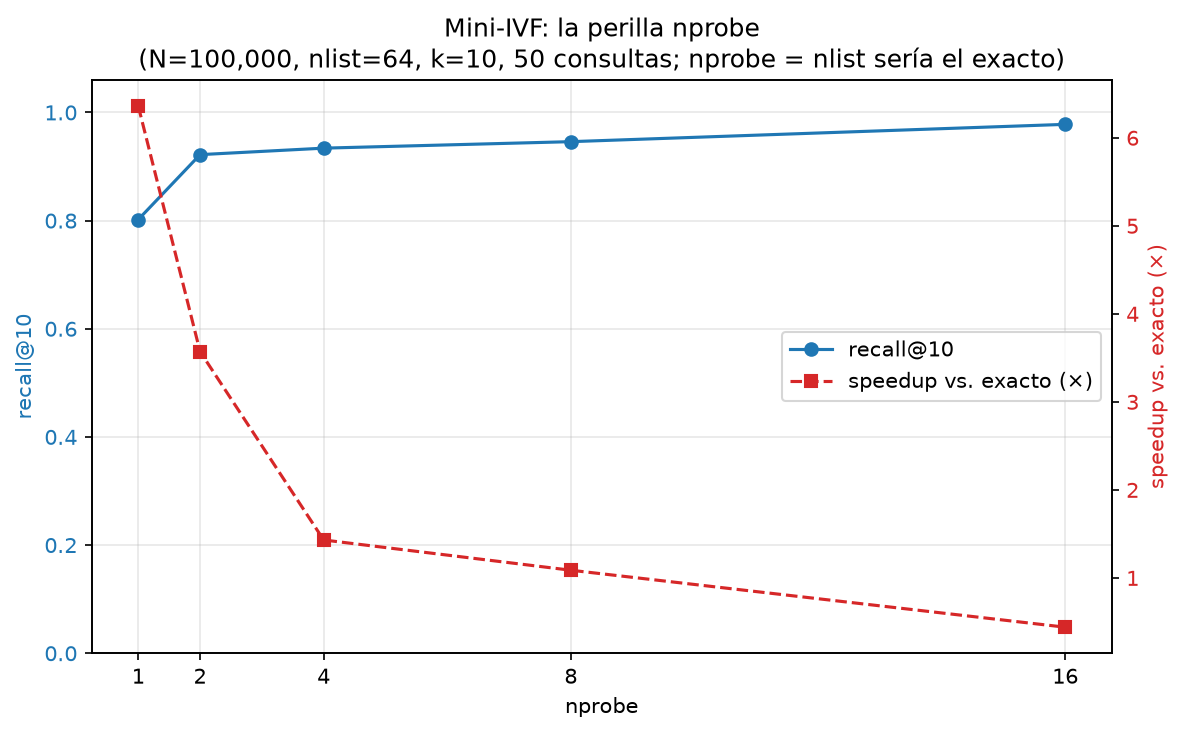

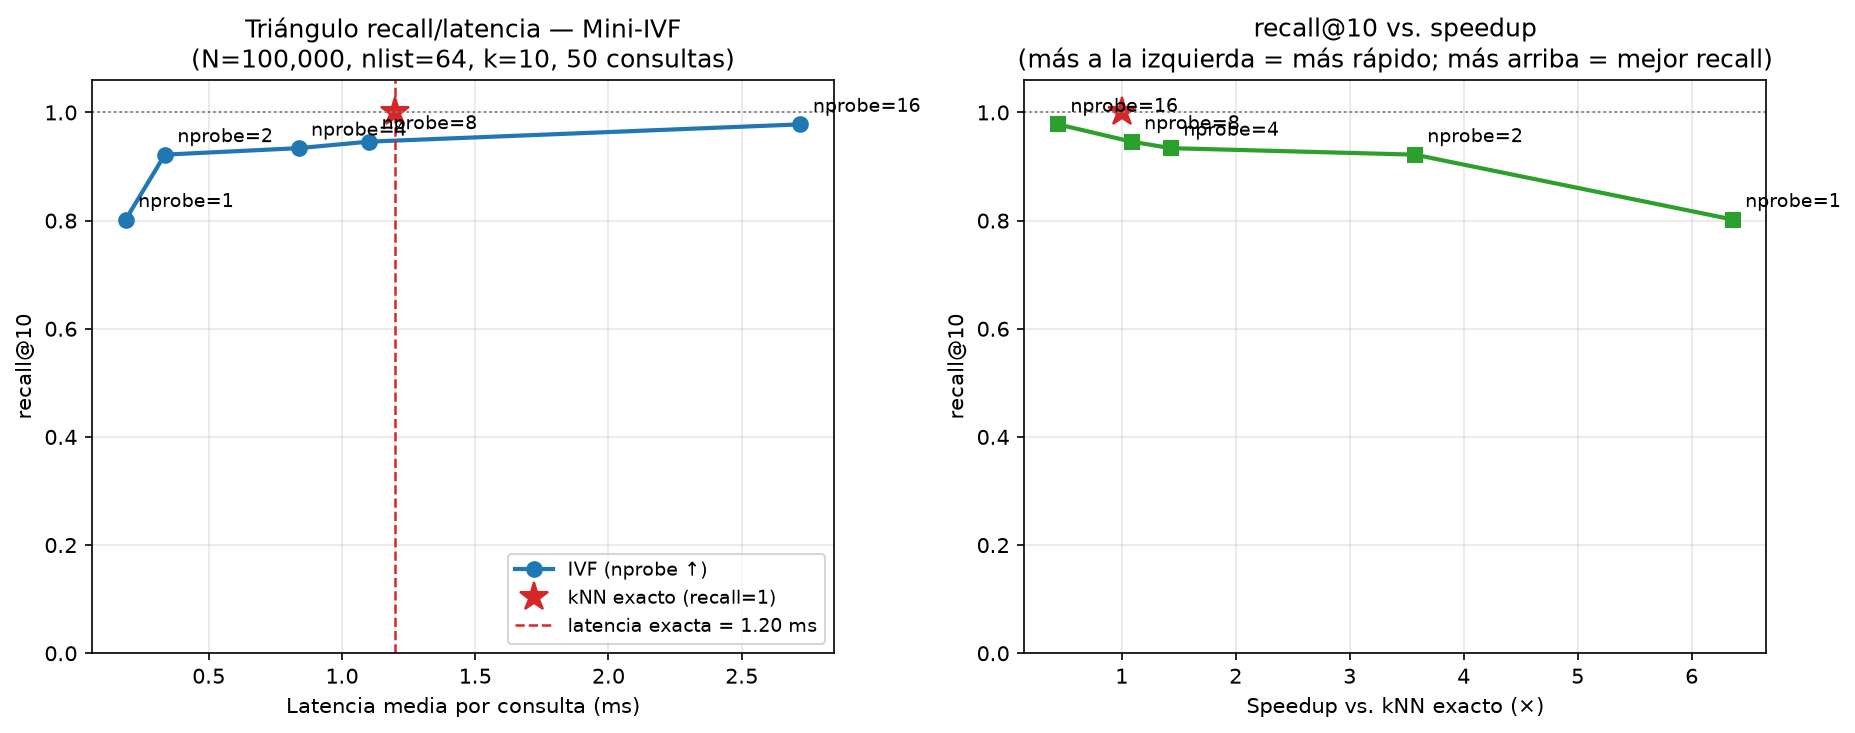

In [3]:
# Subtarea T2: código aprobado (se ejecuta en trabajo/T2/)
os.chdir(RAIZ / 'trabajo' / 'T2')

# -*- coding: utf-8 -*-
"""
T2 — Parte 2: Mini-IVF con KMeans: recall@10 vs. speedup según nprobe.

Receta IVF (slides S2):
  (1) offline  : k-means agrupa los N vectores en nlist celdas;
  (2) consulta : comparar contra los nlist centroides (barato) y buscar
                 EXACTO solo dentro de las nprobe celdas más cercanas.

Se mide sobre 50 consultas, para nprobe in {1, 2, 4, 8, 16}:
  - recall@10 contra kNN exacto,
  - speedup de latencia vs. la búsqueda exacta,
y se reporta la tabla del "triángulo recall/latencia", el tamaño medio de
celda y las figuras PNG correspondientes.

Salidas (carpeta actual, rutas relativas):
  - resultados.json
  - T2_parte2_triangulo_recall_latencia.png
  - T2_parte2_recall_y_speedup_por_nprobe.png
"""

import json
import os
import time

import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# ======================================================================
# 0) Setup — replicación EXACTA del código dado en el enunciado
# ======================================================================
rng = np.random.default_rng(7)                                    # generador de datos
D = 128                                                           # dimensión
_CENTROS = np.random.default_rng(2026).normal(size=(200, D))      # "temas" fijos


def datos_realistas(n, d=D):
    """Embeddings sintéticos CON estructura: mezcla de 'temas' gaussianos fijos.
    Base y consultas comparten los mismos temas, como en un corpus real."""
    asignacion = rng.integers(0, len(_CENTROS), size=n)
    X = _CENTROS[asignacion, :d] + 1.5 * rng.normal(size=(n, d))
    return X.astype(np.float32)


def normalizar(X):
    """Vectores a norma 1: así el producto punto es el coseno."""
    return X / np.linalg.norm(X, axis=-1, keepdims=True)


N = 100_000
NLIST = 64
K = 10                    # k del kNN (recall@10)
N_CONSULTAS = 50
NPROBES = [1, 2, 4, 8, 16]

print(f"Generando base sintética con estructura: N={N:,}, D={D} ...")
base = normalizar(datos_realistas(N))
consultas = normalizar(datos_realistas(N_CONSULTAS))   # mismos 'temas' que la base
print(f"base: {base.shape} ({base.dtype}) | consultas: {consultas.shape}")

# ======================================================================
# 1) Entrenamiento offline del Mini-IVF
# ======================================================================
print(f"Entrenando KMeans(n_clusters={NLIST}, n_init=3, random_state=7) "
      f"sobre {N:,} vectores ...")
t0 = time.perf_counter()
km = KMeans(n_clusters=NLIST, n_init=3, random_state=7).fit(base)
t_kmeans_s = time.perf_counter() - t0

centroides = normalizar(km.cluster_centers_.astype(np.float32))
celdas = [np.where(km.labels_ == c)[0] for c in range(NLIST)]   # índices GLOBALES por celda
tamano_celdas = np.array([len(c) for c in celdas], dtype=np.int64)
tamano_medio_celda = float(tamano_celdas.mean())
n_celdas_vacias = int((tamano_celdas == 0).sum())

print(f"IVF entrenado en {t_kmeans_s:.1f} s: {NLIST} celdas, "
      f"tamaño medio {tamano_medio_celda:.0f} "
      f"(min={int(tamano_celdas.min())}, max={int(tamano_celdas.max())}, "
      f"vacías={n_celdas_vacias})")

# ======================================================================
# 2) kNN exacto (referencia) y knn_ivf
# ======================================================================
def knn_exacto(consulta, k=K):
    """kNN exacto sobre TODA la base (vectores normalizados → dot = coseno).
    Devuelve (índices_globales, scores) ordenados por similitud descendente."""
    scores = base @ consulta                        # O(N·d)
    k_eff = min(k, scores.shape[0])
    idx = np.argpartition(-scores, k_eff - 1)[:k_eff]
    idx = idx[np.argsort(-scores[idx])]
    return idx, scores[idx]


def knn_ivf(consulta, nprobe, k=K):
    """IVF: 1) scores contra los NLIST centroides → nprobe celdas más cercanas
            2) kNN exacto SOLO dentro de esas celdas (¡índices globales!)."""
    scores_centroides = centroides @ consulta               # barato: NLIST·d
    elegidas = np.argsort(-scores_centroides)[:nprobe]
    idx_globales = np.concatenate([celdas[c] for c in elegidas])
    scores_locales = base[idx_globales] @ consulta          # exacto dentro de las celdas
    k_eff = min(k, idx_globales.shape[0])
    parte = np.argpartition(-scores_locales, k_eff - 1)[:k_eff]
    parte = parte[np.argsort(-scores_locales[parte])]
    return idx_globales[parte], scores_locales[parte]


def celdas_mas_cercanas(consulta, nprobe):
    """Solo para contabilidad: cuántos candidatos se escanean con este nprobe."""
    scores_centroides = centroides @ consulta
    elegidas = np.argsort(-scores_centroides)[:nprobe]
    return int(sum(len(celdas[c]) for c in elegidas))


# calentamiento (evita el ruido de la primera llamada en las mediciones)
_ = knn_exacto(consultas[0])
_ = knn_ivf(consultas[0], nprobe=1)

# --- referencia exacta: índices + latencia por consulta (mismas 50 consultas) ---
idx_exactos, lat_exactas_ms = [], []
for q in consultas:
    t0 = time.perf_counter()
    idx_e, _ = knn_exacto(q)
    lat_exactas_ms.append((time.perf_counter() - t0) * 1e3)
    idx_exactos.append(idx_e)
lat_exacta_media_ms = float(np.mean(lat_exactas_ms))
lat_exacta_std_ms = float(np.std(lat_exactas_ms))
print(f"\nkNN exacto: latencia media {lat_exacta_media_ms:.3f} ms/consulta "
      f"(std {lat_exacta_std_ms:.3f} ms)")

# ======================================================================
# 3) Barrido de nprobe: recall@10 y speedup sobre las 50 consultas
# ======================================================================
recall_at10_por_nprobe = {}
recall_std_por_nprobe = {}
speedup_por_nprobe = {}
latencia_ivf_ms_por_nprobe = {}
candidatos_medios_por_nprobe = {}

for nprobe in NPROBES:
    recalls, lats = [], []
    for qi, q in enumerate(consultas):
        t0 = time.perf_counter()
        idx_ivf, _ = knn_ivf(q, nprobe)
        lats.append((time.perf_counter() - t0) * 1e3)
        recalls.append(len(np.intersect1d(idx_ivf, idx_exactos[qi])) / K)
    lat_media = float(np.mean(lats))
    recall_at10_por_nprobe[nprobe] = float(np.mean(recalls))
    recall_std_por_nprobe[nprobe] = float(np.std(recalls))
    latencia_ivf_ms_por_nprobe[nprobe] = lat_media
    speedup_por_nprobe[nprobe] = lat_exacta_media_ms / lat_media
    candidatos_medios_por_nprobe[nprobe] = float(
        np.mean([celdas_mas_cercanas(q, nprobe) for q in consultas]))

# --- tabla del triángulo recall/latencia ---
print("\n=== Triángulo recall/latencia — Mini-IVF "
      f"(N={N:,}, nlist={NLIST}, k={K}, {N_CONSULTAS} consultas) ===")
print(f"{'nprobe':>6} | {'recall@10':>10} | {'lat IVF (ms)':>13} | "
      f"{'speedup×':>9} | {'candidatos':>11}")
print("-" * 68)
print(f"{'exacto':>6} | {'1.0000':>10} | {lat_exacta_media_ms:>13.3f} | "
      f"{1.0:>9.2f} | {N:>11,}")
for nprobe in NPROBES:
    print(f"{nprobe:>6} | {recall_at10_por_nprobe[nprobe]:>10.4f} | "
          f"{latencia_ivf_ms_por_nprobe[nprobe]:>13.3f} | "
          f"{speedup_por_nprobe[nprobe]:>9.2f} | "
          f"{int(round(candidatos_medios_por_nprobe[nprobe])):>11,}")
print(f"\nTamaño medio de celda: {tamano_medio_celda:.1f} vectores "
      f"(N/nlist = {N / NLIST:.0f})")

# ======================================================================
# 4) Figuras
# ======================================================================
lat_ivf = [latencia_ivf_ms_por_nprobe[np_] for np_ in NPROBES]
recalls = [recall_at10_por_nprobe[np_] for np_ in NPROBES]
speedups = [speedup_por_nprobe[np_] for np_ in NPROBES]

# Figura 1: el triángulo recall/latencia
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5))

ax = axes[0]
ax.plot(lat_ivf, recalls, "o-", color="tab:blue", lw=2, ms=7, label="IVF (nprobe ↑)")
for np_, x, y in zip(NPROBES, lat_ivf, recalls):
    ax.annotate(f"nprobe={np_}", (x, y), textcoords="offset points",
                xytext=(6, 6), fontsize=9)
ax.plot([lat_exacta_media_ms], [1.0], "*", color="tab:red", ms=14,
        label="kNN exacto (recall=1)")
ax.axvline(lat_exacta_media_ms, color="tab:red", ls="--", lw=1.2,
           label=f"latencia exacta = {lat_exacta_media_ms:.2f} ms")
ax.axhline(1.0, color="gray", ls=":", lw=1)
ax.set_xlabel("Latencia media por consulta (ms)")
ax.set_ylabel("recall@10")
ax.set_title("Triángulo recall/latencia — Mini-IVF\n"
             f"(N={N:,}, nlist={NLIST}, k={K}, {N_CONSULTAS} consultas)")
ax.set_ylim(0, 1.06)
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(speedups, recalls, "s-", color="tab:green", lw=2, ms=7)
for np_, x, y in zip(NPROBES, speedups, recalls):
    ax.annotate(f"nprobe={np_}", (x, y), textcoords="offset points",
                xytext=(6, 6), fontsize=9)
ax.plot([1.0], [1.0], "*", color="tab:red", ms=14)
ax.axhline(1.0, color="gray", ls=":", lw=1)
ax.set_xlabel("Speedup vs. kNN exacto (×)")
ax.set_ylabel("recall@10")
ax.set_title("recall@10 vs. speedup\n(más a la izquierda = más rápido; "
             "más arriba = mejor recall)")
ax.set_ylim(0, 1.06)
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig("T2_parte2_triangulo_recall_latencia.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print("\nFigura guardada: T2_parte2_triangulo_recall_latencia.png")

# Figura 2: recall y speedup en función de nprobe (la "perilla")
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(NPROBES, recalls, "o-", color="tab:blue", label="recall@10")
ax1.set_xticks(NPROBES)
ax1.set_xticklabels([str(x) for x in NPROBES])
ax1.set_xlabel("nprobe")
ax1.set_ylabel("recall@10", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_ylim(0, 1.06)
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(NPROBES, speedups, "s--", color="tab:red", label="speedup vs. exacto (×)")
ax2.set_ylabel("speedup vs. exacto (×)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="center right")
ax1.set_title("Mini-IVF: la perilla nprobe\n"
              f"(N={N:,}, nlist={NLIST}, k={K}, {N_CONSULTAS} consultas; "
              "nprobe = nlist sería el exacto)")
fig.tight_layout()
fig.savefig("T2_parte2_recall_y_speedup_por_nprobe.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print("Figura guardada: T2_parte2_recall_y_speedup_por_nprobe.png")

# ======================================================================
# 5) Referencia cruzada con T1 (si el archivo está disponible)
# ======================================================================
ref_t1 = None
ruta_t1 = os.path.join("entradas", "T1.json")
if os.path.exists(ruta_t1):
    try:
        with open(ruta_t1, "r", encoding="utf-8") as f:
            t1 = json.load(f)
        lm = t1.get("latencia_media_ms_por_N")
        lat_t1_100k = None
        if isinstance(lm, dict):
            for clave in (100000, "100000", "100_000", "100k"):
                if clave in lm:
                    lat_t1_100k = float(lm[clave])
                    break
        elif isinstance(lm, (list, tuple)) and len(lm) >= 3:
            # orden del enunciado Parte 1: N = 10k, 50k, 100k, 200k → índice 2 = 100k
            lat_t1_100k = float(lm[2])
        ref_t1 = {"latencia_media_ms_por_N": lm, "latencia_100k_ms": lat_t1_100k}
        if lat_t1_100k is not None:
            print(f"\nReferencia T1 (kNN exacto, N=100k): {lat_t1_100k:.3f} ms/consulta "
                  f"| medido aquí: {lat_exacta_media_ms:.3f} ms")
    except Exception as exc:
        print(f"Aviso: no se pudo usar entradas/T1.json ({exc})")
        ref_t1 = None

# ======================================================================
# 6) Guardar todas las cifras en resultados.json
# ======================================================================
resultados = {
    "subtarea": "T2 - Parte 2: Mini-IVF con KMeans, recall@10 vs. speedup",
    "parametros": {
        "N": int(N),
        "D": int(D),
        "NLIST": int(NLIST),
        "kmeans": {"n_clusters": int(NLIST), "n_init": 3, "random_state": 7},
        "k": int(K),
        "n_consultas": int(N_CONSULTAS),
        "nprobes": [int(x) for x in NPROBES],
        "semilla_rng_datos": 7,
        "semilla_centros_temas": 2026,
    },
    "tamano_medio_celda": tamano_medio_celda,
    "tamano_celdas_min": int(tamano_celdas.min()),
    "tamano_celdas_max": int(tamano_celdas.max()),
    "n_celdas_vacias": n_celdas_vacias,
    "tamano_celdas": [int(v) for v in tamano_celdas],
    "recall_at10_por_nprobe": {int(np_): float(recall_at10_por_nprobe[np_])
                               for np_ in NPROBES},
    "recall_at10_std_por_nprobe": {int(np_): float(recall_std_por_nprobe[np_])
                                   for np_ in NPROBES},
    "speedup_por_nprobe": {int(np_): float(speedup_por_nprobe[np_])
                           for np_ in NPROBES},
    "latencia_ivf_ms_por_nprobe": {int(np_): float(latencia_ivf_ms_por_nprobe[np_])
                                   for np_ in NPROBES},
    "candidatos_medios_por_nprobe": {int(np_): float(candidatos_medios_por_nprobe[np_])
                                     for np_ in NPROBES},
    "latencia_exacta_media_ms": lat_exacta_media_ms,
    "latencia_exacta_std_ms": lat_exacta_std_ms,
    "tiempo_entrenamiento_kmeans_s": float(t_kmeans_s),
    "figura_triangulo": "T2_parte2_triangulo_recall_latencia.png",
    "figura_por_nprobe": "T2_parte2_recall_y_speedup_por_nprobe.png",
    "referencia_T1": ref_t1,
    "notas": ("nprobe pequeño → speedup grande pero se pierden vecinos de las "
              "fronteras entre celdas; subir nprobe recupera recall pagando "
              "latencia. nprobe = nlist (=64) equivale a la búsqueda exacta."),
}

with open("resultados.json", "w", encoding="utf-8") as f:
    json.dump(resultados, f, indent=2, ensure_ascii=False)
print("\nResultados guardados en resultados.json")

# ======================================================================
# 7) Cifras principales (resumen final)
# ======================================================================
print("\n=== CIFRAS PRINCIPALES ===")
print(f"tamano_medio_celda = {tamano_medio_celda:.4f}")
print(f"latencia_exacta_media_ms = {lat_exacta_media_ms:.4f}")
for np_ in NPROBES:
    print(f"nprobe={np_:>2}: recall@10 = {recall_at10_por_nprobe[np_]:.4f} | "
          f"speedup = {speedup_por_nprobe[np_]:.2f}x | "
          f"latencia IVF = {latencia_ivf_ms_por_nprobe[np_]:.3f} ms | "
          f"candidatos medios = {candidatos_medios_por_nprobe[np_]:.0f}")

os.chdir(RAIZ)
mostrar_figuras(RAIZ / 'trabajo' / 'T2')

> «La receta: (1) k-means agrupa la base en nlist celdas; (2) en consulta, comparar solo contra los centroides y buscar exacto dentro de las nprobe celdas más cercanas.»

### Entrenamiento del índice (fuera de línea)

Con N = 100,000 y D = 128: `KMeans(n_clusters=64, n_init=3, random_state=7)` sobre la base normalizada → NLIST = 64 celdas en 3.5677 s de entrenamiento. Tamaños de celda: media 1562.5 vectores (N/nlist = 1562), mínimo 463, máximo 3710, 0 celdas vacías. Los centroides se re-normalizan para puntuar con coseno.

### Ejercicio 2.1 — `knn_ivf(consulta, nprobe, k)`

(1) scores de la consulta contra los 64 centroides → las nprobe celdas más cercanas; (2) kNN exacto (k = 10) solo dentro de esas celdas, recuperando los **índices globales** de cada celda.

### Ejercicio 2.2 — recall@10 vs. speedup según nprobe

50 consultas; nprobe ∈ {1, 2, 4, 8, 16}. Referencia exacta medida en esta parte: 1.2561 ms de media (std 0.2286); la Parte 1 midió 1.1636 ms a N = 100k con su propio protocolo.

| nprobe | recall@10 | std recall@10 | Latencia IVF (ms) | Speedup vs. exacto | Candidatos medios |
|---:|---:|---:|---:|---:|---:|
| 1 | 0.8020 | 0.3701 | 0.1990 | 6.3131 | 1711.92 |
| 2 | 0.9220 | 0.2138 | 0.3936 | 3.1913 | 3416.70 |
| 4 | 0.9340 | 0.1751 | 0.7102 | 1.7687 | 6607.72 |
| 8 | 0.9460 | 0.1627 | 1.1777 | 1.0666 | 12636.08 |
| 16 | 0.9780 | 0.0610 | 2.8894 | 0.4347 | 24851.88 |

**Lectura — el triángulo recall/latencia.** Con nprobe = 1 se escanea ~1 celda (1711.92 candidatos de media) y se logra 6.3131x de speedup, pero recall@10 = 0.8020: **dónde se pierde el recall es en las fronteras entre celdas**. Subir nprobe recupera recall pagando latencia: con nprobe = 2 ya se alcanza 0.9220 a 3.1913x; a partir de ahí la curva se aplana (0.9340 → 0.9460 → 0.9780) mientras la latencia sube hasta 2.8894 ms con nprobe = 16 — más lento que el exacto (speedup 0.4347), consistente con que el barrido por celdas sobre 24851.88 candidatos medios no amortiza frente al producto punto vectorizado del exacto sobre los 100,000 vectores. Recordatorio del curso: nprobe = nlist (= 64) equivale a la búsqueda exacta — la aproximación es un dial, no otro algoritmo. HNSW ofrece el mismo dial (`ef_search`) con mejor curva — por eso es el default de las vector DBs.



*Figura T2 — `T2_parte2_recall_y_speedup_por_nprobe.png` (recall@10 y speedup vs. nprobe) y `T2_parte2_triangulo_recall_latencia.png` (triángulo recall/latencia del dial nprobe).*

## Parte 3 — Qdrant embebido: una vector DB real sin Docker

> ⚠️ **Estado de esta parte: la subtarea T3 (Qdrant embebido con filtros de metadata) falló tras 3 intentos.** No hay código ejecutado ni cifras medidas de Qdrant en este entregable: la creación de la colección, el upsert y la consulta con filtro no llegaron a ejecutarse con éxito, por lo que cualquier score, conteo de puntos o resultado de hits de esta parte **no está disponible**.

La mecánica que esta parte debía ejercitar (según el código dado en el enunciado) queda documentada a título descriptivo, sin ejecución:

- **Corpus**: 6 FAQs con payload `{"texto", "tema"}` (temas: cuenta, pagos, soporte, api).
- **`embed_demo`**: vector de 64 dimensiones determinista por documento, con semilla derivada de `hashlib.sha256(texto)` — y no `hash()`, que cambia entre procesos; con un servidor persistente los vectores deben ser iguales en cada corrida.
- **Conexión**: primero se intenta el servidor en `http://localhost:6333` (timeout 3 s); si no responde, `QdrantClient(":memory:")` — modo embebido, sin Docker.
- **Colección `faqs`**: se recrea desde cero si existe (el servidor persiste entre corridas), con `VectorParams(size=64, distance=Distance.COSINE)`; `upsert` de `PointStruct(id, vector, payload)` y verificación con `count`.
- **Consulta con filtro de metadata**: `query_points` con `query=embed_demo("¿cuándo me devuelven el dinero?")`, `query_filter=Filter(must=[FieldCondition(key="tema", match=MatchValue(value="pagos"))])` y `limit=2`.
- Nota del profesor: con embeddings sintéticos el score no es semántico — el objetivo es la **MECÁNICA** de colección/upsert/query/filtro.

## Cierre

- **kNN exacto**: O(N·d), lineal — se mide, no se asume. Medido hoy: R² = 0.9938, factor de crecimiento lineal 1.0621 (21.2415x de latencia para 20x de datos entre N = 10k y 200k; pendiente 0.0128 µs/vector).
- **IVF**: carpetas + nprobe; **HNSW**: grafo jerárquico + ef_search. Mismo triángulo: recall / latencia / memoria. Medido hoy: nprobe = 1 → recall@10 = 0.8020 con 6.3131x; nprobe = 2 → 0.9220 con 3.1913x; nprobe = 16 → 0.9780 con 0.4347x.
- **Qdrant**: colección → upsert(vector+payload) → query con filtros. Mecánica descrita en la Parte 3; **no ejecutada** (subtarea fallida).

### Lo que faltó

- **T3 (Parte 3: Qdrant embebido con filtros de metadata): fallida tras 3 intentos.** Sin código ejecutado ni cifras medidas de Qdrant en este notebook.

### Reflexión final

**a) ¿Necesitas un índice ANN o te basta kNN exacto?** Depende del N estimado de tu proyecto, y hoy tenemos la curva medida, no una suposición: el exacto cuesta 0.1220 ms a N = 10,000 y 2.5913 ms a N = 200,000, con crecimiento lineal verificado (R² = 0.9938; factor 1.0621). Es decir, la latencia por consulta escala proporcionalmente a N: si tu N estimado queda en el orden de 10⁴–10⁵ documentos, el exacto basta para uso interactivo (0.1220–1.1636 ms medidos); si queda en millones y hay tráfico real, el costo lineal lo descarta — el «esto muere» del enunciado. El índice ANN compra la salida, con cifras de la Parte 2: a N = 100,000, nprobe = 2 logra recall@10 = 0.9220 a 3.1913x de speedup (0.3936 ms frente a 1.2561 ms del exacto sobre las mismas 50 consultas), y nprobe = 1 llega a 6.3131x con recall 0.8020. La decisión es elegir el punto del dial recall/latencia que el producto tolere.

**b) ¿Qué motor usarías y por qué operacionalmente?** Razonamiento operacional (sin medición propia de Qdrant hoy, por la falla de T3): si el corpus ya vive en PostgreSQL y el N es moderado, **pgvector** evita operar un servicio adicional — backups, permisos y consultas SQL/JOIN sobre la misma base. Si la búsqueda vectorial es el núcleo del producto o N/QPS crecen, un motor dedicado como **Qdrant** aporta lo que la Parte 3 debía ejercitar: colecciones con upsert(vector + payload), filtros de metadata dentro de la propia query y HNSW por defecto (las notas del curso: «HNSW ofrece el mismo dial (ef_search) con mejor curva — por eso es el default de las vector DBs»), con la ventaja operativa del modo embebido (`:memory:`) para desarrollo sin Docker y de servidor para producción.

Mañana: armamos el pipeline RAG completo — y descubrimos que el chunking importa más que el índice.